<a href="https://colab.research.google.com/github/gagangowda31ku-png/Music-Recommendation-System/blob/main/Song_Recommendation_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SPOtify million song Recommendation system

In [1]:
import numpy as np
import pandas as pd
import os
import json
from zipfile import ZipFile
import re
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import difflib

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [3]:
df = pd.read_csv("spotify_millsongdata.csv.zip")

In [4]:
df

,artist,song,link,text
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA..."
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen..."
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...
...,...,...,...,...
57645,Ziggy Marley,Good Old Days,/z/ziggy+marley/good+old+days_10198588.html,Irie days come on play \r\nLet the angels fly...
57646,Ziggy Marley,Hand To Mouth,/z/ziggy+marley/hand+to+mouth_20531167.html,Power to the workers \r\nMore power \r\nPowe...
57647,Zwan,Come With Me,/z/zwan/come+with+me_20148981.html,all you need \r\nis something i'll believe \...
57648,Zwan,Desire,/z/zwan/desire_20148986.html,northern star \r\nam i frightened \r\nwhere ...


In [5]:
df = df.drop("link",axis=1).reset_index(drop = True)

In [6]:
df

,artist,song,text
0,ABBA,Ahe's My Kind Of Girl,"Look at her face, it's a wonderful face \r\nA..."
1,ABBA,"Andante, Andante","Take it easy with me, please \r\nTouch me gen..."
2,ABBA,As Good As New,I'll never know why I had to go \r\nWhy I had...
3,ABBA,Bang,Making somebody happy is a question of give an...
4,ABBA,Bang-A-Boomerang,Making somebody happy is a question of give an...
...,...,...,...
57645,Ziggy Marley,Good Old Days,Irie days come on play \r\nLet the angels fly...
57646,Ziggy Marley,Hand To Mouth,Power to the workers \r\nMore power \r\nPowe...
57647,Zwan,Come With Me,all you need \r\nis something i'll believe \...
57648,Zwan,Desire,northern star \r\nam i frightened \r\nwhere ...


In [7]:
import warnings
warnings.filterwarnings("ignore")

In [8]:
df = df.sample(10000)

In [ ]:
combined_text = " ".join(df['text'].dropna())
print(combined_text)

In [ ]:
combined_text

In [11]:
word_cloud = WordCloud(width = 800,height = 400,background_color = "white").generate(combined_text)
print(word_cloud)

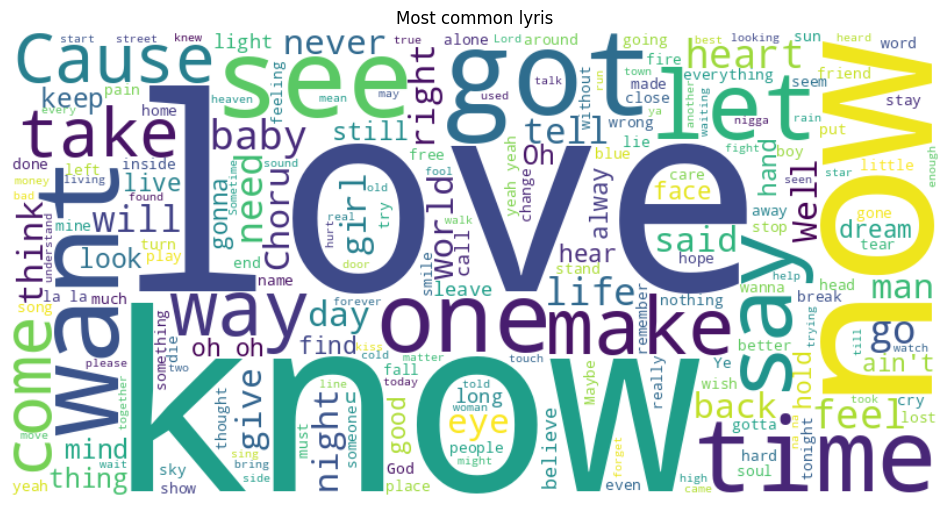

In [12]:
plt.figure(figsize=(12,12))
plt.imshow(word_cloud,interpolation = 'bilinear')
plt.axis('off')
plt.title("Most common lyris")
plt.show()

In [13]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
# getting the stop_words
stop_words = set(stopwords.words("english"))


In [15]:
def preprocess_text(text):
    #removing special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]"," ",text)
    # converting text to lower case
    text = text.lower()
    # tokenizing each text
    tokens = word_tokenize(text)
    #removing the stopwords from tokens
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

In [16]:
df['cleaned_text'] = df['text'].apply(preprocess_text)

In [17]:
df

,artist,song,text,cleaned_text
38488,Johnny Cash,Father And Son,"It's not time to make a change, just relax, an...",time make change relax take easy still young f...
2485,Cheap Trick,Speak Now Or Forever Hold Your Peace,Yesterday feels like running away \r\nFeels l...,yesterday feels like running away feels like g...
15844,Pet Shop Boys,Shameless,I know what you think \r\nIt's clear as mud i...,know think clear mud eyes plastic poseurs pros...
46026,Nirvana,"Endless, Nameless",Silence \r\nHere I am \r\nHere I am \r\nSil...,silence silent bright clear died uhhhh uhhhh u...
6396,Frank Zappa,"Daddy, Daddy, Daddy",[includes a quote from Tell Me You Love Me] \...,includes quote tell love ooo ooo like new car ...
...,...,...,...,...
6886,Glee,It's All Coming Back To Me Now,There were nights when the wind was so cold \...,nights wind cold body froze bed listened right...
37254,Isley Brothers,Put Yourself In My Place,Put yourself in my place \r\nIf only for a da...,put place day see stand awful hurt feel inside...
40171,Kid Rock,Son Of Detroit,"Come on, yeah \r\nI like to play Hank William...",come yeah like play hank williams jr records l...
27808,Christmas Songs,Ding Dong! Merrily On High,"[Refrain:] \r\nDing dong! Merrily on high, \...",refrain ding dong merrily high heav n bells ri...


In [18]:
# converting the text data into feature vector
vectorizer = TfidfVectorizer()
feature_vector = vectorizer.fit_transform(df['cleaned_text'])
similarity = cosine_similarity(feature_vector,feature_vector)
print(similarity)

[[1.         0.1372331  0.0393163  ... 0.0248975  0.01055355 0.02400504]
 [0.1372331  1.         0.01772744 ... 0.03579737 0.0017146  0.02822528]
 [0.0393163  0.01772744 1.         ... 0.00345023 0.         0.00278305]
 ...
 [0.0248975  0.03579737 0.00345023 ... 1.         0.00119866 0.00200408]
 [0.01055355 0.0017146  0.         ... 0.00119866 1.         0.        ]
 [0.02400504 0.02822528 0.00278305 ... 0.00200408 0.         1.        ]]


In [19]:
def recommend_song(song_name, similarity = similarity, df = df , top_n = 10):
    idx = df[df["song"].str.lower() == song_name.lower()].index

    if len(idx) == 0:
        print("song not found in dataset")
    idx = idx[0]
    similarity_score = list(enumerate(similarity[idx]))
    sorted_similarity_score = sorted(similarity_score , key = lambda x : x[1],reverse  = True)

    sorted_similarity_score = sorted_similarity_score[ :top_n]
    ind = [song[0] for song in sorted_similarity_score]
    title_from_index = df.iloc[ind][['artist','song']]
    print(f" - {title_from_index}")



In [20]:
# Recoomending the top 10 song based the similarity score
song = input("%%%%%% ^^^^^^ Enter your favourate movie:  ")
recommend_song(song)


%%%%%% ^^^^^^ Enter your favourate movie:  Daddy, Daddy, Daddy
 -               artist                              song
24165  Andy Williams  The Wonderful World Of The Young
8760   Irving Berlin           They Say It's Wonderful
41371    Leann Rimes            What A Wonderful World
30119   Donna Summer                 Christmas Is Here
52521           Styx                         Young Man
43338    Matt Redman                   Wonderful Maker
25426     Billy Joel          The Night Is Still Young
30080     Don McLean                    Wonderful Baby
12600    Matt Redman                            Gloria
54500     Uriah Heep                   A Year Or A Day
